In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.optimize import minimize
from scipy.optimize import root

Popisy k bunkám boli inšpirované zadaním "Rozcvička 3"

## Predstavenie funkcie
Máme funkciu :
$$f(x, y) = (x^2-y^2)\ln (x^2 + y^2)$$

## Úloha 1

Do jedného grafického okna uložíme dva grafy vedľa seba. Jeden z nich zobrazí graf funkcie  $f(x,y)$, druhý zase graf jej úrovňových množín.

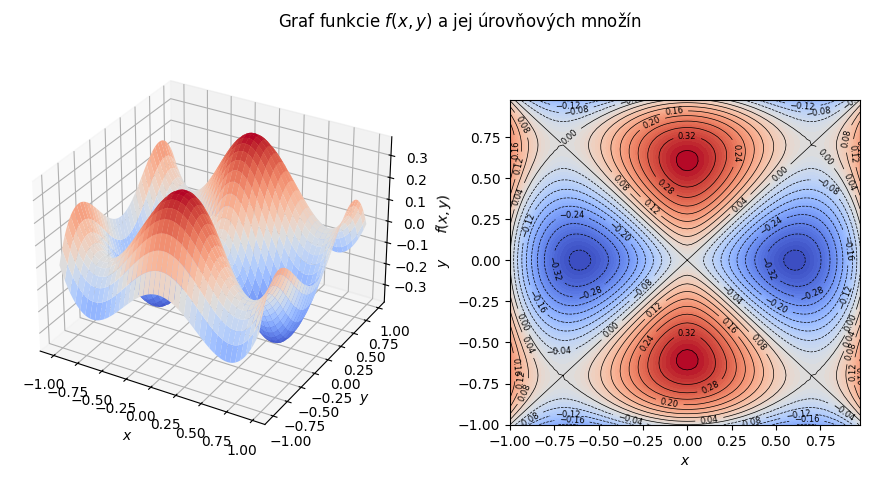

<Figure size 640x480 with 0 Axes>

In [ ]:
# Vytvorenie mriežky, na ktorej sa zobrazuje funkcia
x = np.arange(-1, 1, 0.025)
y = np.arange(-1, 1, 0.025)
X, Y = np.meshgrid(x, y)

# Výpočet funkčných hodnôt
Z = ((X**2) - (Y**2)) * np.log((X**2) + (Y**2))

# Vytvorenie grafického okna
fig = plt.figure(figsize=(10,5))

# Graf funkcie
ax = fig.add_axes([0.05,0.05,0.4,0.9], projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$f(x,y)$')

# Graf jej úrovňových množín
ax = fig.add_axes([0.55,0.15,0.35,0.65])
CS = ax.contour(X, Y, Z, 20,colors='k',linewidths=0.5)
ax.clabel(CS, fontsize=6, inline=True)
ax.contourf(X, Y, Z,80, cmap=cm.coolwarm)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

# Nadpis
fig.suptitle(r'Graf funkcie $f(x,y)$ a jej úrovňových množín')
plt.show()
plt.savefig("graf_zakl.png")

## Úloha 2

Pomocou funkcie ```minimize``` nájdeme všetky lokálne minimá a maximá funkcie  $f(x,y)$.

Pre maximalizáciu sme použili starý známy trik.
$$\max f\left(x, y\right) = -\min \left(-f\left(x, y\right)\right)$$

In [ ]:
# funkcia hľadajúca extrémy
def fun(b, sign=1):
  x, y = b
  return sign * (((x)**2 - (y)**2) * np.log((x)**2 + (y)**2))

# body z, ktorých by sme chceli "spadnúť do minima"
m1 = np.array([-1, 0])
m2 = np.array([1, 0])

# body z, ktorých by sme chceli "spadnúť do maxima"
M1 = np.array([0, -1])
M2 = np.array([0, 1])

minimum1 = minimize(fun, m1)
minimum2= minimize(fun, m2)
maximum1 = minimize(fun, M1, args=(-1,))
maximum2 = minimize(fun, M2, args=(-1,))

print(f"Výsledok hľadania minima1: ")
print(f"Hlásenie: {minimum1.message}")
print(f"f(x, y): {minimum1.fun}")
print(f"(x, y): {minimum1.x}")
print()

print(f"Výsledok hľadania minima2: ")
print(f"Hlásenie: {minimum2.message}")
print(f"f(x, y): {minimum2.fun}")
print(f"(x, y): {minimum2.x}")
print()

print(f"Výsledok hľadania maxima1: ")
print(f"Hlásenie: {maximum1.message}")
print(f"f(x, y): {-maximum1.fun}")
print(f"(x, y): {maximum1.x}")
print()

print(f"Výsledok hľadania maxima2: ")
print(f"Hlásenie: {maximum2.message}")
print(f"f(x, y): {-maximum2.fun}")
print(f"(x, y): {maximum2.x}")

Výsledok hľadania minima1: 
Hlásenie: Optimization terminated successfully.
f(x, y): -0.36787944117115084
(x, y): [6.06530288e-01 8.60946863e-08]

Výsledok hľadania minima2: 
Hlásenie: Optimization terminated successfully.
f(x, y): -0.36787944117117116
(x, y): [-6.06530302e-01  8.61467844e-08]

Výsledok hľadania maxima1: 
Hlásenie: Optimization terminated successfully.
f(x, y): 0.3678794411711431
(x, y): [1.05227595e-07 6.06530287e-01]

Výsledok hľadania maxima2: 
Hlásenie: Optimization terminated successfully.
f(x, y): 0.36787944117117105
(x, y): [ 8.61467845e-08 -6.06530302e-01]


### Report Minimize

Na grafe nižšie môžeme vidieť body, ktoré našla funkcia minimize. symboly "+" reprezentujú lok. max a symboly "-" reprezentuju lok. min.

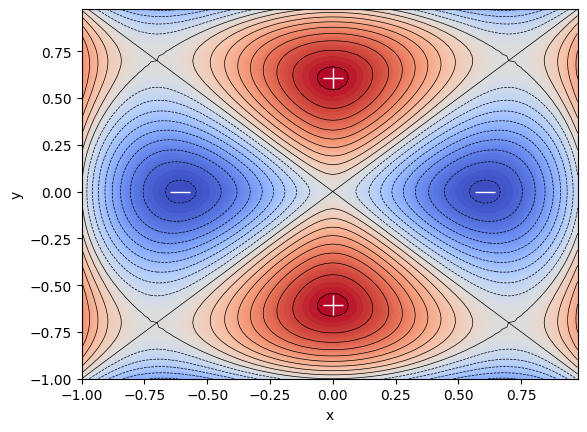

In [ ]:
### hodnoty nadobudnuté funkciou minimize sú numerickými approx. hodnôt v M_x ... m_y

### maxim
M_x = np.array([0, 0])
M_y = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
### minim
m_x = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
m_y = np.array([0, 0])

fig, ax = plt.subplots()
CS = ax.contour(X, Y, Z, 20,colors='k',linewidths=0.5)
ax.contourf(X, Y, Z,80, cmap=cm.coolwarm)
# ax.set_axis_off()

ax.plot(M_x, M_y, marker="+", color="white",linestyle="None", markersize=15)
ax.plot(m_x, m_y, marker="_", color="white",linestyle="None", markersize=15)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

### Úloha 3

Nájdeme všetky stacionárne body funkcie  $f(x,y)$ pomocou funkice `root` ako riešenia sústavy

\begin{align}
 0 = \frac{\partial f}{\partial y} & = 2x\ln{\left(x^2 + y^2\right)} + 2x\frac{x^2 - y^2}{x^2 + y^2}, \\
 0 = \frac{\partial f}{\partial y} & = -2y\ln{\left(x^2 + y^2\right)} + 2y\frac{x^2 - y^2}{x^2 + y^2}.
\end{align}



In [ ]:
def fun(b):
  x, y = b
  ### posledná rada bodov S_1 ... S_4 hlásia division error od logaritmu
  with np.errstate(divide='ignore', invalid='ignore'):
    return [2*x*(np.log((x**2) + (y**2)) + ((x**2) - (y**2))/((x**2) + (y**2))),
  -2*y*(np.log((x**2) + (y**2)) - ((x**2) - (y**2))/((x**2) + (y**2)))]

epsilon = 1/100

# body z, ktorých by sme chceli "spadnúť do minima"
m1 = np.array([-1, 0])
m2 = np.array([1, 0])
# body z, ktorých by sme chceli "spadnúť do maxima"
M1 = np.array([0, -1])
M2 = np.array([0, 1])
# body z, ktorých by sme chceli "spadnúť do sediel"
s1 = np.array([-1, -1])
s2 = np.array([1, -1])
s3 = np.array([1, -1])
s4 = np.array([1, 1])


### vyzera ze solver to nevie solvnut treba to obicyklovat.

# body z, ktorých by sme chceli "spadnúť do vynimočného sedla (0, 0)"
S1 = np.array([-epsilon, -epsilon])
S2 = np.array([epsilon, -epsilon])
S3 = np.array([-epsilon, epsilon])
S4 = np.array([epsilon, epsilon])



m1_root = root(fun, m1)
m2_root = root(fun, m2)
M1_root = root(fun, M1)
M2_root = root(fun, M2)

s1_root = root(fun, s1)
s2_root = root(fun, s2)
s3_root = root(fun, s3)
s4_root = root(fun, s4)

S1_root = root(fun, S1)
S2_root = root(fun, S2)
S3_root = root(fun, S3)
S4_root = root(fun, S4)

print(f"Výsledok optimalizácie pre bod m1: ")
print(f"Hlásenie: {m1_root.message}")
print(f"(df/dx, df/dy): {m1_root.fun}")
print(f"(x, y): {m1_root.x}")
print()

print(f"Výsledok optimalizácie pre bod m2: ")
print(f"Hlásenie: {m2_root.message}")
print(f"(df/dx, df/dy): {m2_root.fun}")
print(f"(x, y): {m2_root.x}")
print()

print(f"Výsledok optimalizácie pre bod M1: ")
print(f"Hlásenie: {M1_root.message}")
print(f"(df/dx, df/dy): {M1_root.fun}")
print(f"(x, y): {M1_root.x}")
print()

print(f"Výsledok optimalizácie pre bod M2: ")
print(f"Hlásenie: {M2_root.message}")
print(f"(df/dx, df/dy): {M2_root.fun}")
print(f"(x, y): {M2_root.x}")

print()
print()
print()
print()
print()

print(f"Výsledok optimalizácie pre bod s1: ")
print(f"Hlásenie: {s1_root.message}")
print(f"(df/dx, df/dy): {s1_root.fun}")
print(f"(x, y): {s1_root.x}")
print()

print(f"Výsledok optimalizácie pre bod s2: ")
print(f"Hlásenie: {s2_root.message}")
print(f"(df/dx, df/dy): {s2_root.fun}")
print(f"(x, y): {s2_root.x}")
print()

print(f"Výsledok optimalizácie pre bod s3: ")
print(f"Hlásenie: {s3_root.message}")
print(f"(df/dx, df/dy): {s3_root.fun}")
print(f"(x, y): {s3_root.x}")
print()

print(f"Výsledok optimalizácie pre bod s4: ")
print(f"Hlásenie: {s4_root.message}")
print(f"(df/dx, df/dy): {s4_root.fun}")
print(f"(x, y): {s4_root.x}")

print()
print()
print()
print()
print()

print(f"Výsledok optimalizácie pre bod S1: ")
print(f"Hlásenie: {S1_root.message}")
print(f"(df/dx, df/dy): {S1_root.fun}")
print(f"(x, y): {S1_root.x}")
print()

print(f"Výsledok optimalizácie pre bod S2: ")
print(f"Hlásenie: {S2_root.message}")
print(f"(df/dx, df/dy): {S2_root.fun}")
print(f"(x, y): {S2_root.x}")
print()

print(f"Výsledok optimalizácie pre bod S3: ")
print(f"Hlásenie: {S3_root.message}")
print(f"(df/dx, df/dy): {S3_root.fun}")
print(f"(x, y): {S3_root.x}")
print()

print(f"Výsledok optimalizácie pre bod S4: ")
print(f"Hlásenie: {S4_root.message}")
print(f"(df/dx, df/dy): {S4_root.fun}")
print(f"(x, y): {S4_root.x}")
print()


Výsledok optimalizácie pre bod m1: 
Hlásenie: The solution converged.
(df/dx, df/dy): [-4.17498268e-14  0.00000000e+00]
(x, y): [-0.60653066  0.        ]

Výsledok optimalizácie pre bod m2: 
Hlásenie: The solution converged.
(df/dx, df/dy): [4.17498268e-14 0.00000000e+00]
(x, y): [0.60653066 0.        ]

Výsledok optimalizácie pre bod M1: 
Hlásenie: The solution converged.
(df/dx, df/dy): [1.47766520e-23 4.17498268e-14]
(x, y): [-3.69416299e-24 -6.06530660e-01]

Výsledok optimalizácie pre bod M2: 
Hlásenie: The solution converged.
(df/dx, df/dy): [-2.02077242e-23 -4.17498268e-14]
(x, y): [5.05193105e-24 6.06530660e-01]





Výsledok optimalizácie pre bod s1: 
Hlásenie: The solution converged.
(df/dx, df/dy): [-3.14018492e-16  3.14018492e-16]
(x, y): [-0.70710678 -0.70710678]

Výsledok optimalizácie pre bod s2: 
Hlásenie: The solution converged.
(df/dx, df/dy): [ 2.85474211e-12 -2.85537015e-12]
(x, y): [ 0.70710678 -0.70710678]

Výsledok optimalizácie pre bod s3: 
Hlásenie: The solution

###Report root
posledný bod $\mathbf{o}$ neskonvergoval tak ako sa patrí, velmi pravdepodobne to je kôli tomu, že gradienty bodov v okolí sú skoro nulové a preto to ten solver nevedel vyriešiť a dať radostnú odpoveď "Solution converged", ale keďže analyticky sme to vyriešili a zároveň zo 4 rôznych smerov sa dostávame k podobným hodnotám tak usudzujem, že je to stacionárny bod napriek nerozhodnosti `root`

nasledujúca bunka vizualizuje body ziskané solvermi, čierne bodky sú body kde je gradient nulový.

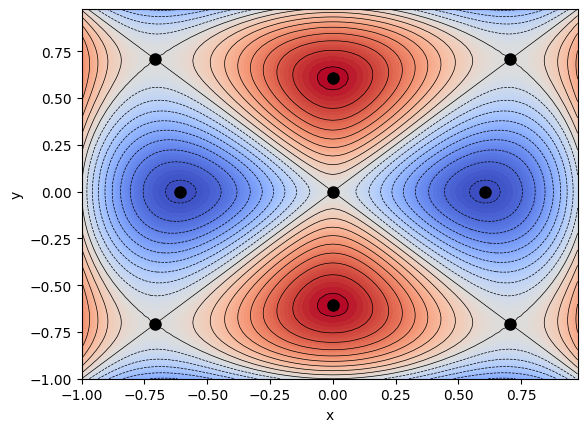

In [ ]:
### sedlá
s_x = np.array([0, np.sqrt(2)/2, np.sqrt(2)/2, -np.sqrt(2)/2, -np.sqrt(2)/2])
s_y = np.array([0, np.sqrt(2)/2, -np.sqrt(2)/2, np.sqrt(2)/2, -np.sqrt(2)/2])

### maxim
M_x = np.array([0, 0])
M_y = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
### minim
m_x = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
m_y = np.array([0, 0])

fig, ax = plt.subplots()
CS = ax.contour(X, Y, Z, 20,colors='k',linewidths=0.5)
ax.contourf(X, Y, Z,80, cmap=cm.coolwarm)
# ax.set_axis_off()

ax.plot(s_x, s_y, marker="o", color="black",linestyle="None", markersize=8)
ax.plot(M_x, M_y, marker="o", color="black",linestyle="None", markersize=8)
ax.plot(m_x, m_y, marker="o", color="black",linestyle="None", markersize=8)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.savefig("grad_nula.png")
plt.show()

### Ilustrácia
Nasledujúce bunky tvoria obrázky, ktoré sa využiju v latexe, ide o znamienkové diagramy aby sme sa vyhli hessianu.

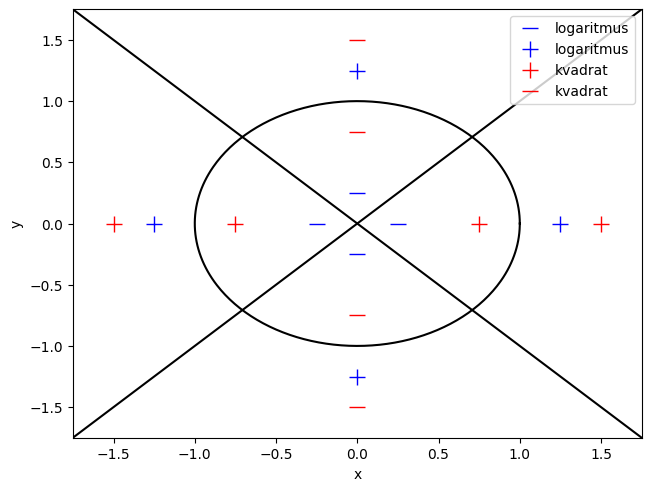

In [ ]:
theta = np.linspace(0, 2*np.pi, 400)
x_kružnica = np.cos(theta)
y_kružnica = np.sin(theta)

x = np.linspace(-1.75, 1.75, 400)
y_1 = x
y_2 = -x

l_x = np.array([1/4, -1/4, 0, 0])
l_y = np.array([0, 0, 1/4, -1/4])
l__x = np.array([5/4, -5/4, 0, 0])
l__y = np.array([0, 0, 5/4, -5/4])

k_x = np.array([3/4, -3/4, 3/2, -3/2])
k_y = np.array([0, 0, 0, 0])
k__x = np.array([0, 0, 0, 0])
k__y = np.array([3/4, -3/4, 3/2, -3/2])

fig1, ax1 = plt.subplots(layout="constrained")

ax1.plot(x_kružnica, y_kružnica, color="black")
ax1.plot(x, y_1, color="black")
ax1.plot(x, y_2, color="black")

ax1.plot(l_x, l_y, marker="_", color="blue", linestyle="None", markersize="12", label="logaritmus")
ax1.plot(l__x, l__y, marker="+", color="blue", linestyle="None", markersize="12", label="logaritmus")
ax1.plot(k_x, k_y, marker="+", color="red", linestyle="None", markersize="12", label="kvadrat")
ax1.plot(k__x, k__y, marker="_", color="red", linestyle="None", markersize="12", label="kvadrat")

ax1.set_xlim(-1.75, 1.75)
ax1.set_ylim(-1.75, 1.75)


# ax1.set_axis_off()

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend(loc="upper right")
plt.savefig("znamienkovy diagram1.png")
plt.show()


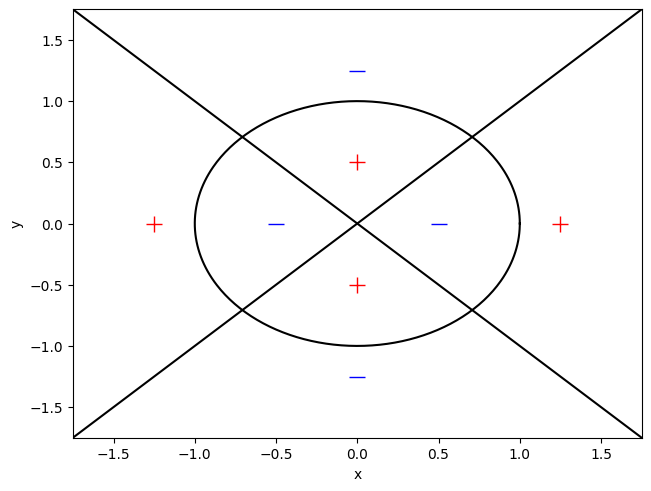

In [ ]:
theta = np.linspace(0, 2*np.pi, 400)
x_kružnica = np.cos(theta)
y_kružnica = np.sin(theta)

x = np.linspace(-1.75, 1.75, 400)
y_1 = x
y_2 = -x

l_x = np.array([0, 0, 5/4, -5/4])
l_y = np.array([1/2, -1/2, 0, 0])
l__x = np.array([1/2, -1/2, 0, 0])
l__y = np.array([0, 0, 5/4, -5/4])


fig1, ax1 = plt.subplots(layout="constrained")

ax1.plot(x_kružnica, y_kružnica, color="black")
ax1.plot(x, y_1, color="black")
ax1.plot(x, y_2, color="black")

ax1.plot(l_x, l_y, marker="+", color="red", linestyle="None", markersize="12")
ax1.plot(l__x, l__y, marker="_", color="blue", linestyle="None", markersize="12")

ax1.set_xlim(-1.75, 1.75)
ax1.set_ylim(-1.75, 1.75)

# ax1.set_axis_off()

ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.savefig("znamienkovy diagram2.png")
plt.show()

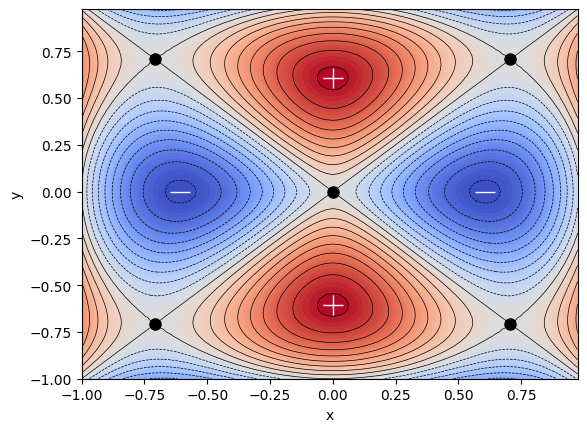

In [ ]:
### sedlá
s_x = np.array([0, np.sqrt(2)/2, np.sqrt(2)/2, -np.sqrt(2)/2, -np.sqrt(2)/2])
s_y = np.array([0, np.sqrt(2)/2, -np.sqrt(2)/2, np.sqrt(2)/2, -np.sqrt(2)/2])

### maxim
M_x = np.array([0, 0])
M_y = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
### minim
m_x = np.array([1/np.sqrt(np.e), -1/np.sqrt(np.e)])
m_y = np.array([0, 0])

fig, ax = plt.subplots()
CS = ax.contour(X, Y, Z, 20,colors='k',linewidths=0.5)
ax.contourf(X, Y, Z,80, cmap=cm.coolwarm)
# ax.set_axis_off()

ax.plot(s_x, s_y, marker="o", color="black",linestyle="None", markersize=8)
ax.plot(M_x, M_y, marker="+", color="white",linestyle="None", markersize=15)
ax.plot(m_x, m_y, marker="_", color="white",linestyle="None", markersize=15)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.savefig("znamienkovy diagram3.png")
plt.show()